# Vision Transformers (ViT): Transformers Conquer Computer Vision

## Learning Objectives

By the end of this notebook, you will:
- Understand **why** transformers work for vision (not just language!)
- Learn how to split images into **patches** and embed them
- Implement **2D positional encodings** for spatial information
- Build a complete **Vision Transformer (ViT)** from scratch
- Compare ViT with traditional **CNNs** on image classification
- Visualize what the model "sees" through **attention patterns**

## The Journey

We'll build a Vision Transformer incrementally:

1. **Motivation** - Why apply transformers to images?
2. **Patch Embedding** - Converting images to sequences
3. **Positional Encodings** - 2D spatial information
4. **Vision Transformer Architecture** - Complete ViT model
5. **Training & Comparison** - ViT vs CNN on CIFAR-10
6. **Attention Visualization** - What does ViT attend to?
7. **Analysis** - Strengths, weaknesses, and insights

**The Big Idea**: Treat an image as a sequence of patches and apply the same transformer architecture we use for text!

## Part 1: The Vision Transformer Revolution

### The Traditional Approach: CNNs

For decades, **Convolutional Neural Networks (CNNs)** dominated computer vision:
- Local receptive fields (3×3 or 5×5 kernels)
- Translation invariance through weight sharing
- Hierarchical feature learning (edges → textures → objects)
- Strong **inductive bias** about images (locality, spatial structure)

### The Transformer Approach: ViT

In 2020, Google Research showed that transformers can **match or exceed** CNN performance:
- Split image into fixed-size **patches** (like words in text)
- Treat patches as a **sequence** and apply self-attention
- **Global receptive field** from layer 1 (every patch can attend to every other)
- Less inductive bias → needs more data, but scales better

### Key Insight

**CNNs**: Local patterns with hierarchical composition

**ViT**: Global relationships from the start with learned spatial understanding

Let's build one to understand how!

## Part 2: Setup

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
import math
from tqdm import tqdm

# Shared utilities
from aiml_notebooks import (
    get_device,
    set_seed,
    count_parameters,
    CIFAR10_MEAN,
    CIFAR10_STD,
    CIFAR10_CLASSES,
    create_standard_transforms,
    imshow_normalized,
    show_image_grid_normalized,
    plot_training_curves,
)

# Enable autoreload
%load_ext autoreload
%autoreload 2

# Set random seed
set_seed(42)

# Device setup
device = get_device()

# Plotting configuration
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## Part 3: Data Preparation

We'll use **CIFAR-10** (32×32 RGB images, 10 classes) - a standard benchmark.

**Why CIFAR-10?**
- Small enough to train quickly
- Large enough to show ViT's capabilities
- Standard benchmark for comparing architectures

In [2]:
# Create transforms
train_transform, test_transform = create_standard_transforms(
    image_size=32,
    mean=CIFAR10_MEAN,
    std=CIFAR10_STD,
    augment=True  # Data augmentation for training
)

# Load CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

print(f"Training images: {len(train_dataset)}")
print(f"Test images: {len(test_dataset)}")
print(f"Classes: {CIFAR10_CLASSES}")

Training images: 50000
Test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Visualize Sample Images

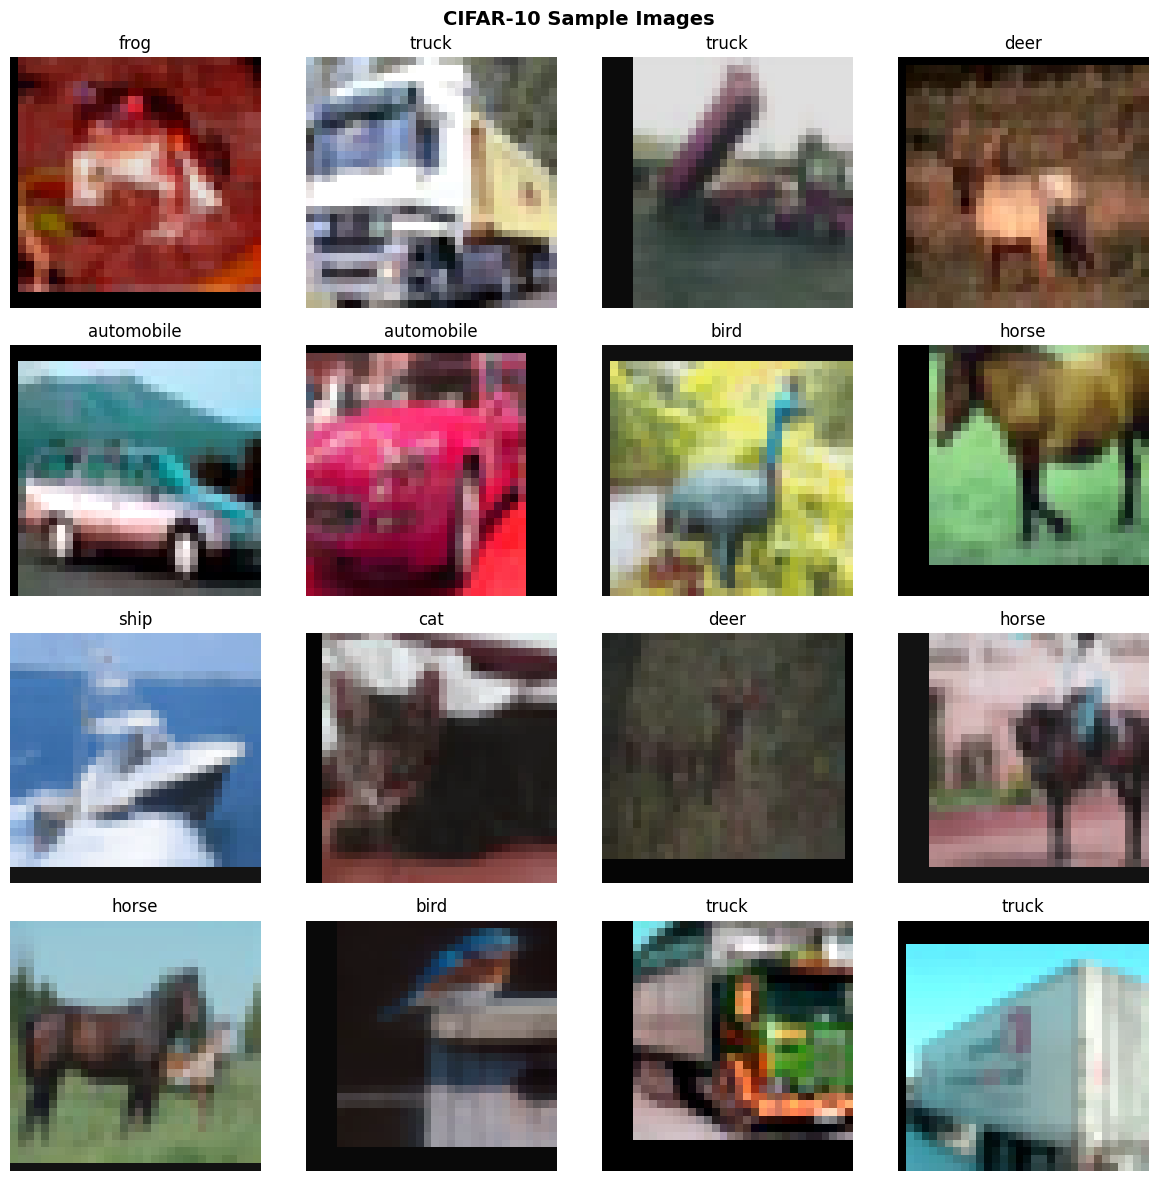

In [3]:
# Show sample images
sample_images = torch.stack([train_dataset[i][0] for i in range(16)])
sample_labels = [train_dataset[i][1] for i in range(16)]

show_image_grid_normalized(
    sample_images,
    mean=CIFAR10_MEAN,
    std=CIFAR10_STD,
    labels=sample_labels,
    class_names=CIFAR10_CLASSES,
    nrows=4,
    ncols=4,
    title='CIFAR-10 Sample Images'
)
plt.show()

## Part 4: Understanding Image Patches

### The Core Idea

**Problem**: Transformers expect a sequence of tokens. Images are 2D grids of pixels.

**Solution**: Split the image into fixed-size **patches** and treat each patch as a "token".

For a 32×32 image with 4×4 patches:
- Each patch is 4×4 = 16 pixels
- We get 8×8 = 64 patches total
- Each patch becomes a single token in our sequence

**Key insight**: Just like words in a sentence, patches in an image have relationships!

Let's visualize this patching process.

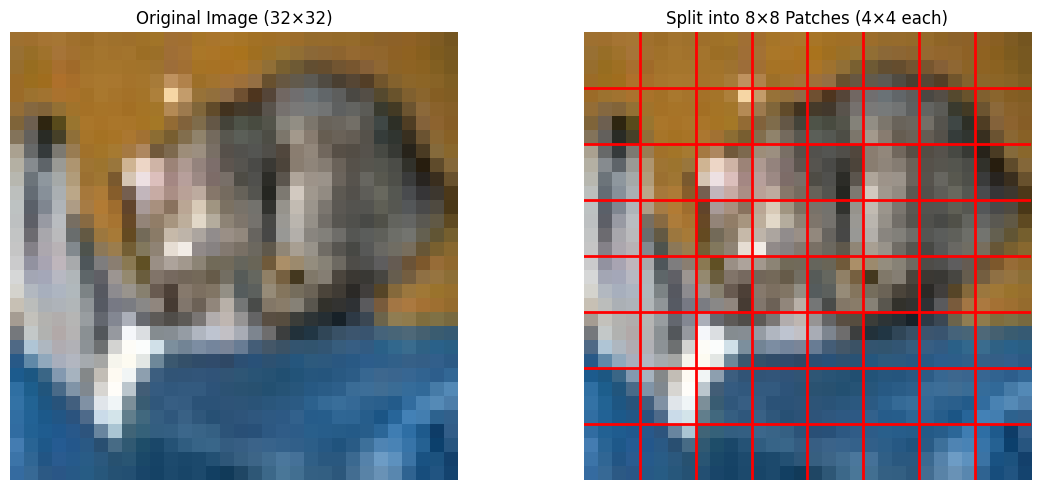

Image shape: (3, 32, 32)
Patch size: 4×4
Number of patches: 64
Each patch has 48 values


In [4]:
def visualize_patches(image, patch_size=4):
    """
    Visualize how an image is split into patches.
    
    Args:
        image: (C, H, W) tensor
        patch_size: Size of each patch
    """
    C, H, W = image.shape
    n_patches_h = H // patch_size
    n_patches_w = W // patch_size
    
    # Create a copy for drawing grid lines
    image_with_grid = image.clone()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Original image
    ax = axes[0]
    img_np = image.permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title('Original Image (32×32)')
    ax.axis('off')
    
    # Image with patch grid
    ax = axes[1]
    ax.imshow(img_np)
    
    # Draw grid lines
    for i in range(1, n_patches_h):
        ax.axhline(y=i*patch_size - 0.5, color='red', linewidth=2)
    for j in range(1, n_patches_w):
        ax.axvline(x=j*patch_size - 0.5, color='red', linewidth=2)
    
    ax.set_title(f'Split into {n_patches_h}×{n_patches_w} Patches ({patch_size}×{patch_size} each)')
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Image shape: {tuple(image.shape)}")
    print(f"Patch size: {patch_size}×{patch_size}")
    print(f"Number of patches: {n_patches_h * n_patches_w}")
    print(f"Each patch has {C * patch_size * patch_size} values")

# Visualize patching on a sample image (unnormalized for visualization)
sample_img, sample_label = test_dataset[0]
# Denormalize for visualization
from aiml_notebooks import denormalize_image
sample_img_denorm = denormalize_image(sample_img, CIFAR10_MEAN, CIFAR10_STD)

visualize_patches(sample_img_denorm, patch_size=4)

### Extracting Patches: The Math

Given an image of shape $(C, H, W)$ and patch size $P$:

1. **Number of patches**: $N = \frac{H}{P} \times \frac{W}{P}$

2. **Each patch**: Flatten to a vector of size $C \times P \times P$

3. **Result**: Sequence of $N$ patches, each of dimension $C \cdot P^2$

For CIFAR-10 (32×32×3) with patch size 4:
- $N = 8 \times 8 = 64$ patches
- Each patch: $3 \times 4 \times 4 = 48$ dimensional

Let's implement this!

In [5]:
def extract_patches(images, patch_size):
    """
    Extract non-overlapping patches from images.
    
    Args:
        images: (B, C, H, W) tensor
        patch_size: Size of each patch
        
    Returns:
        patches: (B, num_patches, patch_dim) tensor
            where patch_dim = C * patch_size * patch_size
    """
    B, C, H, W = images.shape
    
    # Use unfold to extract patches
    # unfold(dimension, size, step)
    patches = images.unfold(2, patch_size, patch_size)  # (B, C, n_patches_h, W, patch_size)
    patches = patches.unfold(3, patch_size, patch_size)  # (B, C, n_patches_h, n_patches_w, patch_size, patch_size)
    
    # Rearrange to (B, num_patches, C*patch_size*patch_size)
    n_patches_h = H // patch_size
    n_patches_w = W // patch_size
    
    patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()  # (B, n_h, n_w, C, P, P)
    patches = patches.view(B, n_patches_h * n_patches_w, C * patch_size * patch_size)
    
    return patches

# Test patch extraction
test_images = sample_images[:4]  # (4, 3, 32, 32)
test_patches = extract_patches(test_images, patch_size=4)

print(f"Input images shape: {test_images.shape}")
print(f"Output patches shape: {test_patches.shape}")
print(f"\nEach image became a sequence of {test_patches.shape[1]} patches")
print(f"Each patch is a {test_patches.shape[2]}-dimensional vector")

Input images shape: torch.Size([4, 3, 32, 32])
Output patches shape: torch.Size([4, 64, 48])

Each image became a sequence of 64 patches
Each patch is a 48-dimensional vector


## Part 5: Patch Embedding Layer

### From Patches to Embeddings

Raw patches are high-dimensional (48-dim for 4×4×3 patches). We want to:
1. Project patches to a learnable embedding space (like word embeddings)
2. Add a learnable **class token** [CLS] (for classification, like BERT)

**Two approaches**:
1. **Linear projection**: Flatten patches and apply linear layer (simple, standard)
2. **Convolutional projection**: Use Conv2d with stride=patch_size (equivalent but more efficient)

We'll use the convolutional approach (it's what the original paper does!).

In [6]:
class PatchEmbedding(nn.Module):
    """
    Convert image into sequence of patch embeddings.
    
    Uses a convolutional layer with kernel_size=patch_size and stride=patch_size
    to extract and embed patches in one operation.
    """
    
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        """
        Args:
            img_size: Input image size (assumes square images)
            patch_size: Size of each patch
            in_channels: Number of input channels (3 for RGB)
            embed_dim: Dimension of patch embeddings
        """
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        # Convolutional projection: extracts patches and embeds them
        self.projection = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )
        
    def forward(self, x):
        """
        Args:
            x: (B, C, H, W) image tensor
            
        Returns:
            (B, num_patches, embed_dim) patch embeddings
        """
        # Apply convolution: (B, C, H, W) -> (B, embed_dim, H/P, W/P)
        x = self.projection(x)
        
        # Flatten spatial dimensions: (B, embed_dim, H/P, W/P) -> (B, embed_dim, num_patches)
        x = x.flatten(2)
        
        # Transpose: (B, embed_dim, num_patches) -> (B, num_patches, embed_dim)
        x = x.transpose(1, 2)
        
        return x

# Test patch embedding
embed_dim = 128
patch_embed = PatchEmbedding(
    img_size=32,
    patch_size=4,
    in_channels=3,
    embed_dim=embed_dim
)

test_embeddings = patch_embed(test_images)
print(f"Input shape: {test_images.shape}")
print(f"Output shape: {test_embeddings.shape}")
print(f"\nEach image → sequence of {test_embeddings.shape[1]} embeddings")
print(f"Each embedding is {test_embeddings.shape[2]}-dimensional")

Input shape: torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 64, 128])

Each image → sequence of 64 embeddings
Each embedding is 128-dimensional


### Adding the Class Token

Like BERT, we add a special **[CLS] token** at the beginning of the sequence:
- Learnable embedding (not from the image)
- Aggregates information from all patches through self-attention
- Used for final classification (take its representation after all layers)

This gives us: `[CLS], patch_1, patch_2, ..., patch_N`

In [7]:
# Class token is a learnable parameter
class_token = nn.Parameter(torch.randn(1, 1, embed_dim))

# Add class token to the beginning of each sequence
batch_size = test_embeddings.shape[0]
cls_tokens = class_token.expand(batch_size, -1, -1)  # (B, 1, embed_dim)
embeddings_with_cls = torch.cat([cls_tokens, test_embeddings], dim=1)  # (B, 1+num_patches, embed_dim)

print(f"Patch embeddings: {test_embeddings.shape}")
print(f"With [CLS] token: {embeddings_with_cls.shape}")
print(f"\nSequence length increased from {test_embeddings.shape[1]} to {embeddings_with_cls.shape[1]}")

Patch embeddings: torch.Size([4, 64, 128])
With [CLS] token: torch.Size([4, 65, 128])

Sequence length increased from 64 to 65


## Part 6: Positional Encodings for Images

### Why Positional Information Matters

Without positional encodings, the transformer can't distinguish:
- Top-left patch from bottom-right patch
- A shuffled image from the original

### Two Approaches for Vision

1. **1D Positional Encoding**: Treat patches as a flat sequence (0, 1, 2, ..., N-1)
   - Simple, works surprisingly well
   - Doesn't explicitly encode 2D spatial structure

2. **2D Positional Encoding**: Separate encodings for row and column
   - More explicit spatial information
   - Slightly better for vision tasks

**Original ViT paper**: Uses **learnable** 1D positional embeddings (simpler, works great!)

Let's implement learnable positional embeddings:

In [8]:
class PositionalEmbedding(nn.Module):
    """
    Learnable positional embeddings for patch sequences.
    
    Each position gets its own learnable vector that's added to the patch embedding.
    """
    
    def __init__(self, num_patches, embed_dim, dropout=0.1):
        """
        Args:
            num_patches: Number of patches (including class token)
            embed_dim: Embedding dimension
            dropout: Dropout probability
        """
        super().__init__()
        # Learnable positional embeddings (including position for class token)
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        """
        Args:
            x: (B, num_patches+1, embed_dim) - patch embeddings with class token
            
        Returns:
            (B, num_patches+1, embed_dim) - with positional information added
        """
        # Add positional embeddings (broadcast across batch)
        x = x + self.pos_embedding
        x = self.dropout(x)
        return x

# Create positional embedding
num_patches = 64  # 8x8 patches
pos_embed = PositionalEmbedding(num_patches, embed_dim)

# Apply to embeddings with class token
embeddings_with_pos = pos_embed(embeddings_with_cls)

print(f"Embeddings with class token: {embeddings_with_cls.shape}")
print(f"After adding positional info: {embeddings_with_pos.shape}")
print(f"\nPositional embeddings shape: {pos_embed.pos_embedding.shape}")
print("Each position has a unique learnable vector!")

Embeddings with class token: torch.Size([4, 65, 128])
After adding positional info: torch.Size([4, 65, 128])

Positional embeddings shape: torch.Size([1, 65, 128])
Each position has a unique learnable vector!


### Visualizing Positional Embeddings

Let's visualize what these learnable embeddings look like (they'll be random initially, but will learn spatial structure during training).

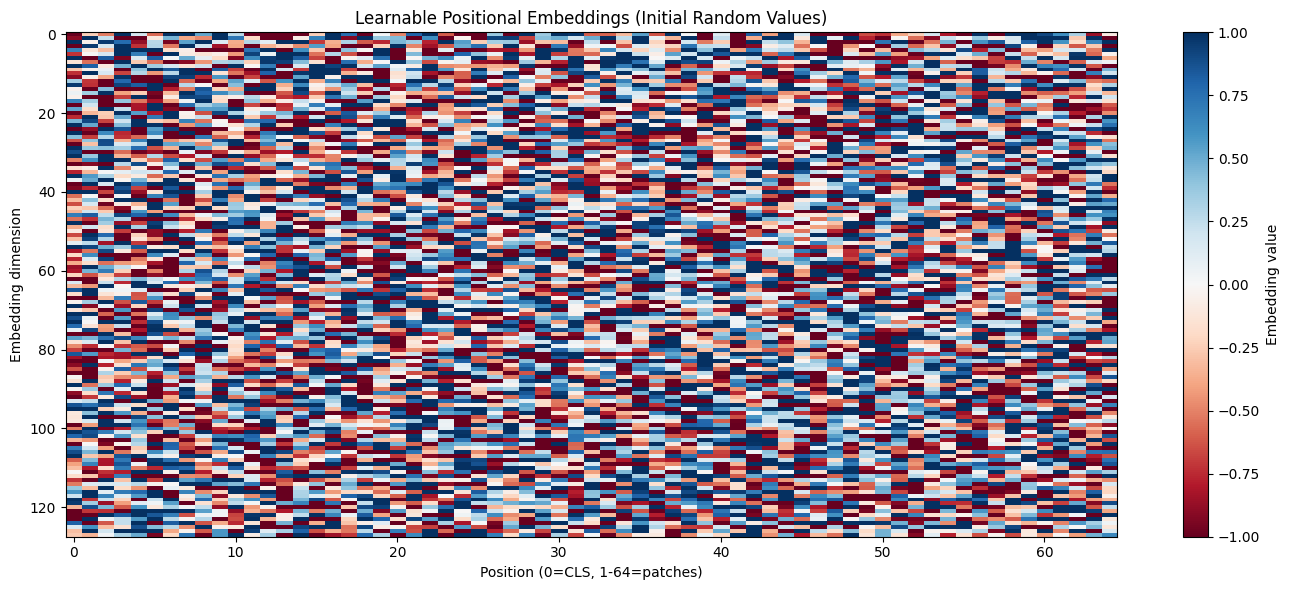

After training, similar positions will have similar embeddings!
The model learns to encode spatial relationships.


In [9]:
# Visualize positional embeddings
pos_emb = pos_embed.pos_embedding[0].detach().numpy()  # (num_patches+1, embed_dim)

plt.figure(figsize=(14, 6))
plt.imshow(pos_emb.T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(label='Embedding value')
plt.xlabel('Position (0=CLS, 1-64=patches)')
plt.ylabel('Embedding dimension')
plt.title('Learnable Positional Embeddings (Initial Random Values)')
plt.tight_layout()
plt.show()

print("After training, similar positions will have similar embeddings!")
print("The model learns to encode spatial relationships.")

## Part 7: Transformer Encoder

### Building on Previous Knowledge

We'll reuse the transformer architecture from the `transformer-from-scratch` notebook:
- Multi-head self-attention
- Feed-forward networks
- Layer normalization and residuals

**Key difference**: No causal masking! (We can attend to all patches simultaneously)

Let's build the core components:

In [10]:
class MultiHeadSelfAttention(nn.Module):
    """
    Multi-head self-attention for Vision Transformer.
    
    Same as standard transformer attention, but without causal masking.
    """
    
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        # QKV projection
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, return_attention=False):
        """
        Args:
            x: (B, N, embed_dim) where N = num_patches + 1
            return_attention: If True, return attention weights
            
        Returns:
            output: (B, N, embed_dim)
            attention: (B, num_heads, N, N) if return_attention=True
        """
        B, N, C = x.shape
        
        # Compute Q, K, V
        qkv = self.qkv(x)  # (B, N, 3*embed_dim)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)  # (B, N, 3, num_heads, head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, num_heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]  # Each: (B, num_heads, N, head_dim)
        
        # Attention scores
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, num_heads, N, N)
        attn = F.softmax(attn, dim=-1)
        attn_weights = attn.clone() if return_attention else None
        attn = self.dropout(attn)
        
        # Apply attention to values
        x = (attn @ v)  # (B, num_heads, N, head_dim)
        x = x.transpose(1, 2)  # (B, N, num_heads, head_dim)
        x = x.reshape(B, N, C)  # (B, N, embed_dim)
        
        # Output projection
        x = self.proj(x)
        x = self.dropout(x)
        
        if return_attention:
            return x, attn_weights
        return x

# Test attention
num_heads = 4
attention = MultiHeadSelfAttention(embed_dim, num_heads)
attn_output = attention(embeddings_with_pos)

print(f"Input shape: {embeddings_with_pos.shape}")
print(f"Output shape: {attn_output.shape}")
print(f"\nAttention allows each patch to look at all other patches!")

Input shape: torch.Size([4, 65, 128])
Output shape: torch.Size([4, 65, 128])

Attention allows each patch to look at all other patches!


### Feed-Forward Network (MLP)

The MLP block processes each patch independently (same as in standard transformers).

In [11]:
class MLP(nn.Module):
    """
    Multi-Layer Perceptron (Feed-Forward Network) for Vision Transformer.
    
    Standard: embed_dim -> 4*embed_dim -> embed_dim with GELU activation.
    """
    
    def __init__(self, embed_dim, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()  # GELU is standard for vision transformers
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

# Test MLP
mlp = MLP(embed_dim)
mlp_output = mlp(attn_output)

print(f"Input shape: {attn_output.shape}")
print(f"Output shape: {mlp_output.shape}")

Input shape: torch.Size([4, 65, 128])
Output shape: torch.Size([4, 65, 128])


### Transformer Encoder Block

Combine attention + MLP with residuals and layer norm (Pre-LN variant):

In [12]:
class TransformerBlock(nn.Module):
    """
    Transformer encoder block for Vision Transformer.
    
    Architecture:
        x = x + Attention(LayerNorm(x))
        x = x + MLP(LayerNorm(x))
    """
    
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout)
        
    def forward(self, x, return_attention=False):
        # Attention with residual
        if return_attention:
            attn_out, attn_weights = self.attn(self.norm1(x), return_attention=True)
            x = x + attn_out
        else:
            x = x + self.attn(self.norm1(x))
            attn_weights = None
        
        # MLP with residual
        x = x + self.mlp(self.norm2(x))
        
        if return_attention:
            return x, attn_weights
        return x

# Test transformer block
transformer_block = TransformerBlock(embed_dim, num_heads)
block_output = transformer_block(embeddings_with_pos)

print(f"Input shape: {embeddings_with_pos.shape}")
print(f"Output shape: {block_output.shape}")
print(f"\nShape preserved - we can stack many blocks!")

Input shape: torch.Size([4, 65, 128])
Output shape: torch.Size([4, 65, 128])

Shape preserved - we can stack many blocks!


## Part 8: Complete Vision Transformer

### Putting Everything Together

Now we combine all components into a complete Vision Transformer:

1. **Patch Embedding**: Image → sequence of patches
2. **Class Token**: Add [CLS] token at the beginning
3. **Positional Embedding**: Add spatial information
4. **Transformer Encoder**: Stack of transformer blocks
5. **Classification Head**: Use [CLS] token for classification

Let's build it!

In [13]:
class VisionTransformer(nn.Module):
    """
    Vision Transformer (ViT) for image classification.
    
    Based on "An Image is Worth 16x16 Words" (Dosovitskiy et al., 2020)
    """
    
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=128,
        depth=6,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.1
    ):
        """
        Args:
            img_size: Input image size
            patch_size: Size of each patch
            in_channels: Number of input channels
            num_classes: Number of classes for classification
            embed_dim: Embedding dimension
            depth: Number of transformer blocks
            num_heads: Number of attention heads
            mlp_ratio: Ratio of MLP hidden dim to embed_dim
            dropout: Dropout probability
        """
        super().__init__()
        
        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches
        
        # Class token
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        
        # Positional embedding
        self.pos_embed = PositionalEmbedding(num_patches, embed_dim, dropout)
        
        # Transformer encoder
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        
        # Final layer norm
        self.norm = nn.LayerNorm(embed_dim)
        
        # Classification head
        self.head = nn.Linear(embed_dim, num_classes)
        
        # Initialize weights
        self._init_weights()
        
    def _init_weights(self):
        # Initialize patch embedding
        nn.init.xavier_uniform_(self.patch_embed.projection.weight)
        nn.init.zeros_(self.patch_embed.projection.bias)
        
        # Initialize class token
        nn.init.normal_(self.cls_token, std=0.02)
        
        # Initialize classification head
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)
        
    def forward(self, x, return_attention=False):
        """
        Args:
            x: (B, C, H, W) input images
            return_attention: If True, return attention weights from last block
            
        Returns:
            logits: (B, num_classes) class logits
            attention: (B, num_heads, N, N) if return_attention=True
        """
        B = x.shape[0]
        
        # Patch embedding: (B, C, H, W) -> (B, num_patches, embed_dim)
        x = self.patch_embed(x)
        
        # Add class token: (B, num_patches, embed_dim) -> (B, 1+num_patches, embed_dim)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        
        # Add positional embeddings
        x = self.pos_embed(x)
        
        # Apply transformer blocks
        attention_weights = None
        for i, block in enumerate(self.blocks):
            # Return attention from last block if requested
            if return_attention and i == len(self.blocks) - 1:
                x, attention_weights = block(x, return_attention=True)
            else:
                x = block(x)
        
        # Final layer norm
        x = self.norm(x)
        
        # Classification: use only the [CLS] token
        cls_output = x[:, 0]  # (B, embed_dim)
        logits = self.head(cls_output)  # (B, num_classes)
        
        if return_attention:
            return logits, attention_weights
        return logits

# Create Vision Transformer
vit = VisionTransformer(
    img_size=32,
    patch_size=4,
    in_channels=3,
    num_classes=10,
    embed_dim=128,
    depth=6,
    num_heads=4,
    mlp_ratio=4.0,
    dropout=0.1
).to(device)

print("Vision Transformer Architecture:")
print(f"  Image size: 32×32")
print(f"  Patch size: 4×4")
print(f"  Num patches: 64")
print(f"  Embed dim: 128")
print(f"  Depth: 6 layers")
print(f"  Num heads: 4")
print(f"  Total parameters: {count_parameters(vit):,}")

Vision Transformer Architecture:
  Image size: 32×32
  Patch size: 4×4
  Num patches: 64
  Embed dim: 128
  Depth: 6 layers
  Num heads: 4
  Total parameters: 1,205,898


### Test Forward Pass

In [14]:
# Test the model
test_batch = test_images.to(device)
with torch.no_grad():
    logits = vit(test_batch)

print(f"Input shape: {test_batch.shape}")
print(f"Output shape: {logits.shape}")
print(f"\n✓ Vision Transformer works!")

# Check predictions
probs = F.softmax(logits, dim=-1)
preds = torch.argmax(probs, dim=-1)
print(f"\nSample predictions (untrained): {preds.cpu().numpy()}")
print(f"Confidence: {probs.max(dim=-1)[0].cpu().numpy()}")

Input shape: torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 10])

✓ Vision Transformer works!

Sample predictions (untrained): [0 0 0 0]
Confidence: [0.1 0.1 0.1 0.1]


## Part 9: Comparison with CNNs

### Building a Comparable CNN

Let's create a CNN with a similar number of parameters to compare architectures.

**CNN Architecture**:
- Convolutional layers with increasing channels
- MaxPooling for spatial reduction
- Global average pooling
- Classification head

In [15]:
class SimpleCNN(nn.Module):
    """
    Simple CNN for comparison with Vision Transformer.
    """
    
    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()
        
        # Convolutional feature extractor
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 32 -> 16
            
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 16 -> 8
            
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 8 -> 4
        )
        
        # Global average pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Classification head
        self.classifier = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Create CNN
cnn = SimpleCNN(in_channels=3, num_classes=10).to(device)

print("CNN Architecture:")
print(f"  Total parameters: {count_parameters(cnn):,}")
print(f"\nComparison:")
print(f"  ViT: {count_parameters(vit):,} parameters")
print(f"  CNN: {count_parameters(cnn):,} parameters")

CNN Architecture:
  Total parameters: 559,178

Comparison:
  ViT: 1,205,898 parameters
  CNN: 559,178 parameters


## Part 10: Training Setup

### Training Configuration

We'll train both models with the same setup:
- Loss: Cross-entropy
- Optimizer: AdamW
- Learning rate: 3e-4 with cosine annealing
- Batch size: 128
- Epochs: 20 (quick training for demonstration)

In [16]:
# Create data loaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 391
Test batches: 79


### Training Functions

In [17]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.3f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    return total_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion, device):
    """Evaluate on test set."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

print("Training functions defined!")

Training functions defined!


### Train Vision Transformer

In [18]:
# Training configuration
num_epochs = 20
learning_rate = 3e-4
weight_decay = 0.01

# Optimizer and criterion
optimizer_vit = torch.optim.AdamW(vit.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler_vit = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_vit, T_max=num_epochs)
criterion = nn.CrossEntropyLoss()

print("Training Vision Transformer...")
print(f"Epochs: {num_epochs}")
print(f"Learning rate: {learning_rate}")
print(f"Weight decay: {weight_decay}")
print()

# Training loop
vit_history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Train
    train_loss, train_acc = train_epoch(vit, train_loader, criterion, optimizer_vit, device)
    
    # Evaluate
    test_loss, test_acc = evaluate(vit, test_loader, criterion, device)
    
    # Step scheduler
    scheduler_vit.step()
    
    # Save history
    vit_history['train_loss'].append(train_loss)
    vit_history['train_acc'].append(train_acc)
    vit_history['test_loss'].append(test_loss)
    vit_history['test_acc'].append(test_acc)
    
    print(f"Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.3f} | Test Acc: {test_acc:.2f}%")

print("\n✓ Vision Transformer training complete!")

Training Vision Transformer...
Epochs: 20
Learning rate: 0.0003
Weight decay: 0.01


Epoch 1/20


Training: 100%|██████████| 391/391 [00:09<00:00, 42.90it/s, loss=2.092, acc=23.11%]


Train Loss: 2.039 | Train Acc: 23.11%
Test Loss: 1.894 | Test Acc: 29.82%

Epoch 2/20


Training: 100%|██████████| 391/391 [00:09<00:00, 40.75it/s, loss=1.753, acc=32.59%]


Train Loss: 1.833 | Train Acc: 32.59%
Test Loss: 1.633 | Test Acc: 41.43%

Epoch 3/20


...

Train Loss: 1.229 | Train Acc: 55.80%
Test Loss: 1.122 | Test Acc: 59.57%

Epoch 19/20


Training: 100%|██████████| 391/391 [00:12<00:00, 30.91it/s, loss=1.333, acc=55.95%]


Train Loss: 1.226 | Train Acc: 55.95%
Test Loss: 1.120 | Test Acc: 59.69%

Epoch 20/20


Training: 100%|██████████| 391/391 [00:13<00:00, 29.14it/s, loss=1.292, acc=56.12%]


Train Loss: 1.222 | Train Acc: 56.12%
Test Loss: 1.121 | Test Acc: 59.59%

✓ Vision Transformer training complete!


### Train CNN for Comparison

In [19]:
# Optimizer and scheduler for CNN
optimizer_cnn = torch.optim.AdamW(cnn.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler_cnn = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_cnn, T_max=num_epochs)

print("Training CNN for comparison...")
print()

# Training loop
cnn_history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Train
    train_loss, train_acc = train_epoch(cnn, train_loader, criterion, optimizer_cnn, device)
    
    # Evaluate
    test_loss, test_acc = evaluate(cnn, test_loader, criterion, device)
    
    # Step scheduler
    scheduler_cnn.step()
    
    # Save history
    cnn_history['train_loss'].append(train_loss)
    cnn_history['train_acc'].append(train_acc)
    cnn_history['test_loss'].append(test_loss)
    cnn_history['test_acc'].append(test_acc)
    
    print(f"Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.3f} | Test Acc: {test_acc:.2f}%")

print("\n✓ CNN training complete!")

Training CNN for comparison...


Epoch 1/20


Training: 100%|██████████| 391/391 [00:12<00:00, 31.45it/s, loss=1.388, acc=48.47%]


Train Loss: 1.426 | Train Acc: 48.47%
Test Loss: 1.265 | Test Acc: 55.12%

Epoch 2/20


Training: 100%|██████████| 391/391 [00:12<00:00, 31.69it/s, loss=0.909, acc=62.54%]


Train Loss: 1.067 | Train Acc: 62.54%
Test Loss: 1.085 | Test Acc: 61.49%

Epoch 3/20


...

Train Loss: 0.400 | Train Acc: 86.32%
Test Loss: 0.451 | Test Acc: 84.37%

Epoch 19/20


Training: 100%|██████████| 391/391 [00:12<00:00, 31.66it/s, loss=0.355, acc=86.75%]


Train Loss: 0.395 | Train Acc: 86.75%
Test Loss: 0.444 | Test Acc: 84.60%

Epoch 20/20


Training: 100%|██████████| 391/391 [00:11<00:00, 34.70it/s, loss=0.437, acc=86.88%]


Train Loss: 0.392 | Train Acc: 86.88%
Test Loss: 0.444 | Test Acc: 84.79%

✓ CNN training complete!


## Part 11: Comparing Vision Transformer vs CNN

### Visualizing Training Curves

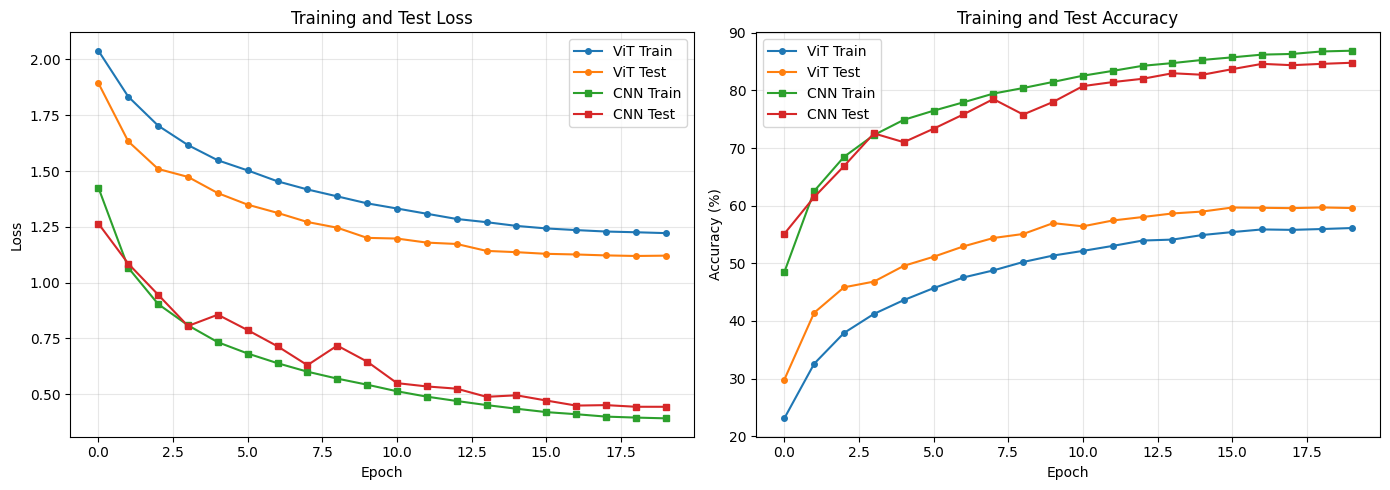


Final Results:
Vision Transformer:
  Test Accuracy: 59.59%
  Test Loss: 1.121
  Parameters: 1,205,898

CNN:
  Test Accuracy: 84.79%
  Test Loss: 0.444
  Parameters: 559,178


In [20]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax = axes[0]
ax.plot(vit_history['train_loss'], label='ViT Train', marker='o', markersize=4)
ax.plot(vit_history['test_loss'], label='ViT Test', marker='o', markersize=4)
ax.plot(cnn_history['train_loss'], label='CNN Train', marker='s', markersize=4)
ax.plot(cnn_history['test_loss'], label='CNN Test', marker='s', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Test Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy curves
ax = axes[1]
ax.plot(vit_history['train_acc'], label='ViT Train', marker='o', markersize=4)
ax.plot(vit_history['test_acc'], label='ViT Test', marker='o', markersize=4)
ax.plot(cnn_history['train_acc'], label='CNN Train', marker='s', markersize=4)
ax.plot(cnn_history['test_acc'], label='CNN Test', marker='s', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training and Test Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final results
print("\nFinal Results:")
print("="*50)
print(f"Vision Transformer:")
print(f"  Test Accuracy: {vit_history['test_acc'][-1]:.2f}%")
print(f"  Test Loss: {vit_history['test_loss'][-1]:.3f}")
print(f"  Parameters: {count_parameters(vit):,}")
print()
print(f"CNN:")
print(f"  Test Accuracy: {cnn_history['test_acc'][-1]:.2f}%")
print(f"  Test Loss: {cnn_history['test_loss'][-1]:.3f}")
print(f"  Parameters: {count_parameters(cnn):,}")

### Analysis: ViT vs CNN

Let's discuss what we observe:

#### Typical Patterns:

**CNNs**:
- Often converge faster initially (strong inductive bias)
- Good performance even with less data
- Local receptive fields → hierarchical feature learning

**Vision Transformers**:
- May start slower (less inductive bias)
- Need more data to reach full potential
- Global attention from layer 1 → can learn long-range dependencies
- Scale better with data and model size

#### Key Insight:

On small datasets like CIFAR-10, CNNs often perform similarly or better due to their **inductive bias** (locality, translation equivariance).

On large datasets (ImageNet, JFT-300M), ViT can **exceed** CNN performance because:
- Less bias → more flexibility to learn
- Better scaling with compute and data
- Can learn spatial relationships rather than hardcoding them

## Part 12: Visualizing Attention

### What Does the Vision Transformer See?

One of the most exciting aspects of ViT is that we can **visualize attention**!

Let's see what patches the model attends to when making predictions.

Visualizing Vision Transformer Attention:



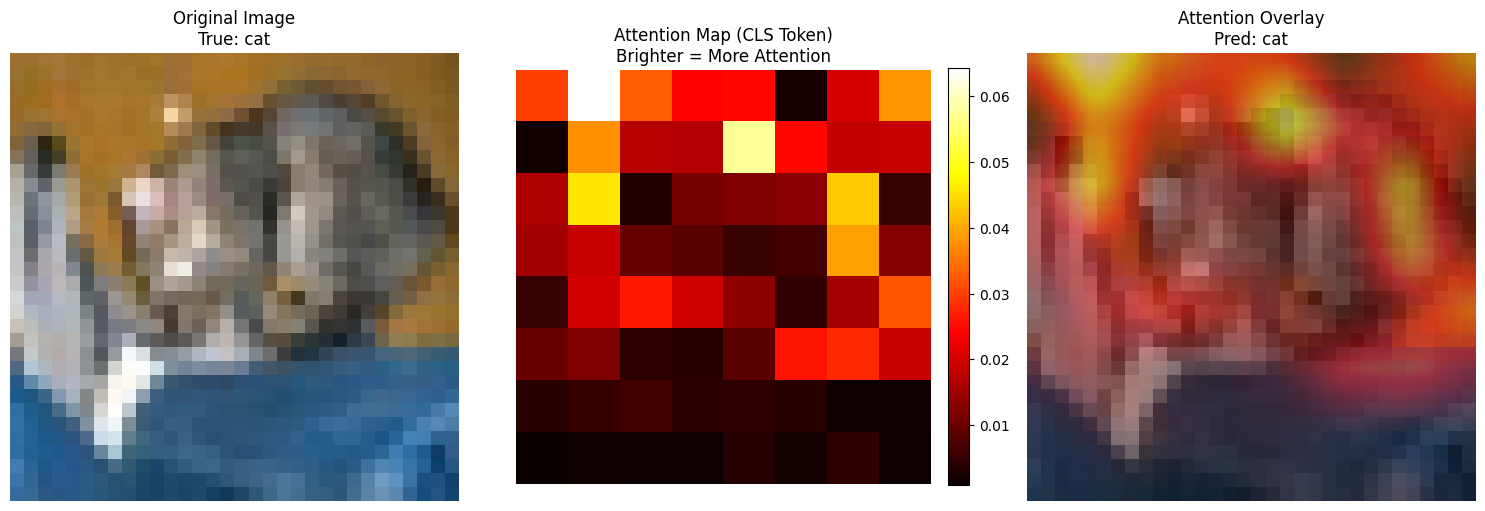

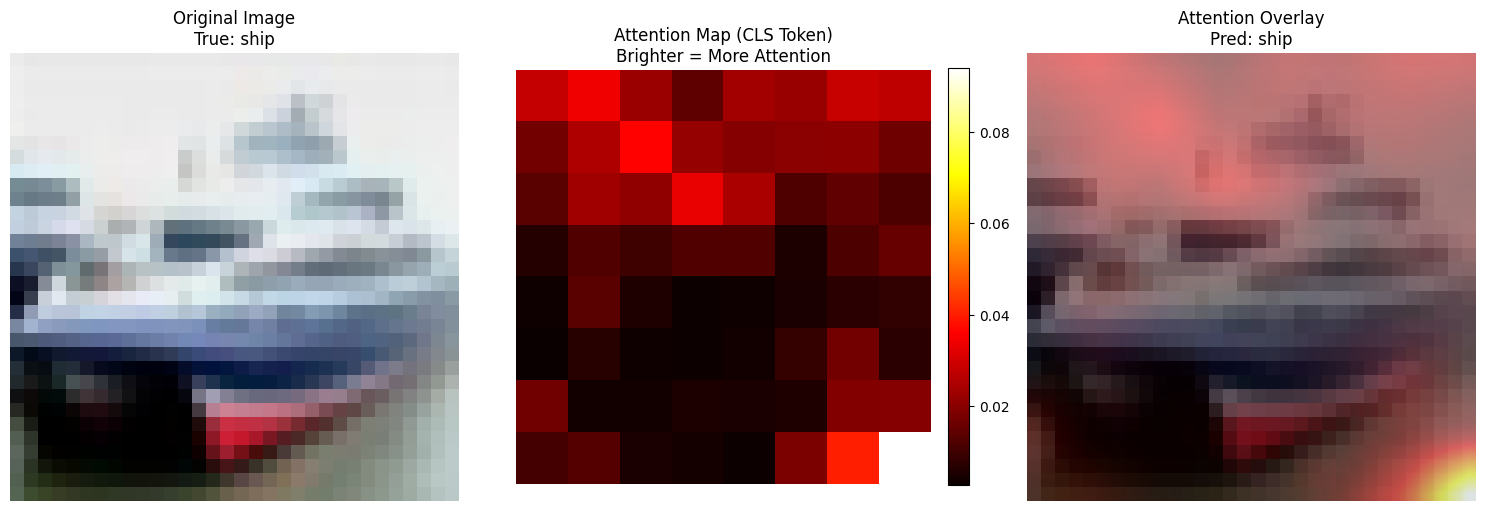

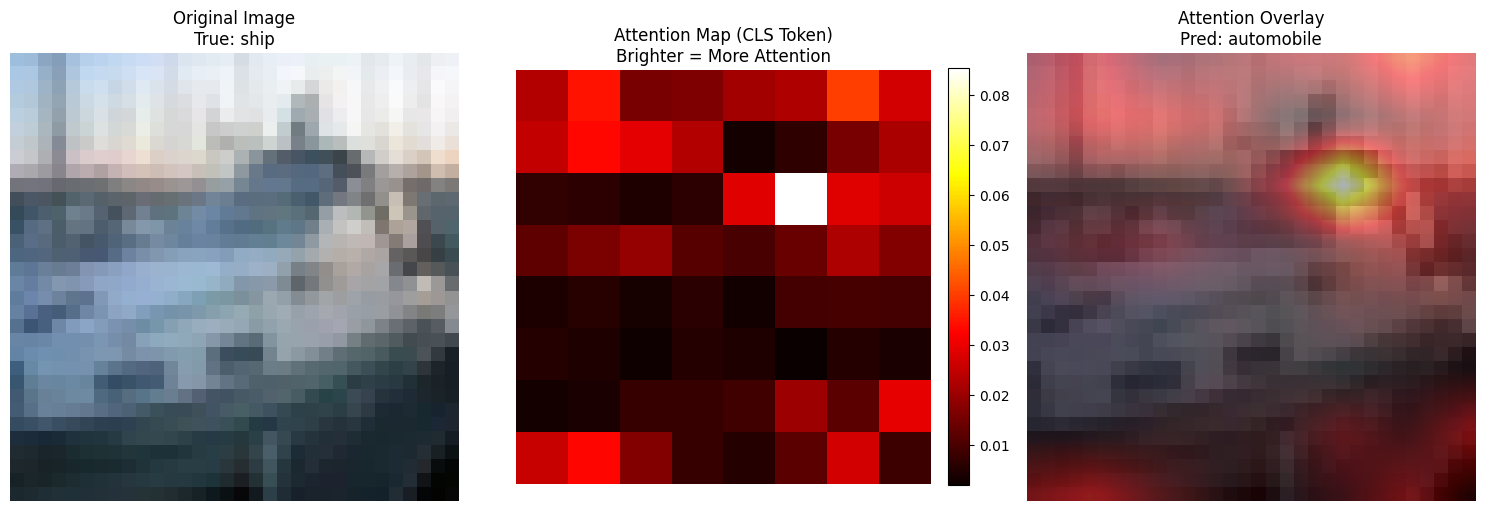

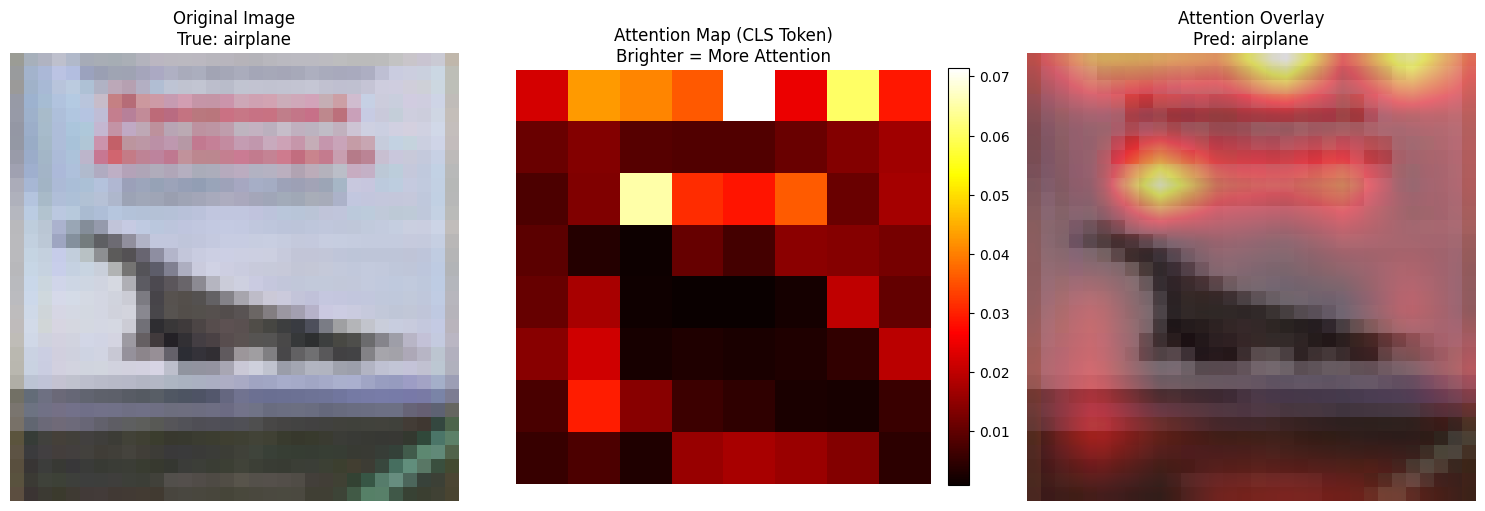

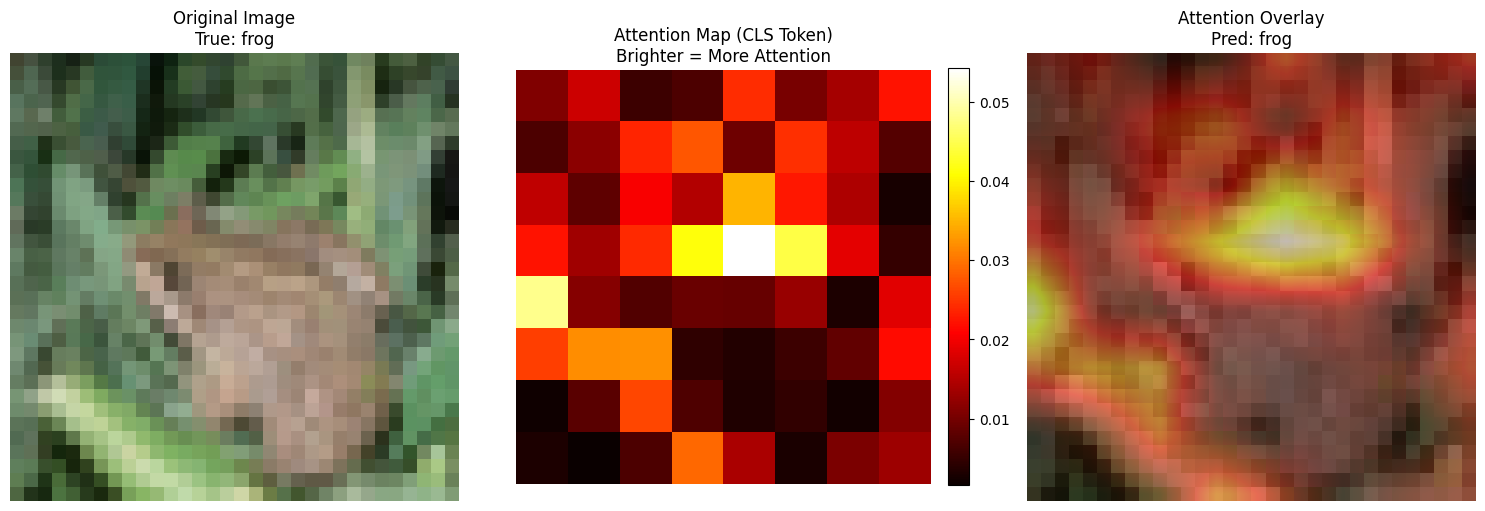

In [21]:
def visualize_attention(model, image, label, mean, std):
    """
    Visualize attention weights from the last layer.
    
    Shows which patches the [CLS] token attends to.
    """
    model.eval()
    
    # Get attention weights
    with torch.no_grad():
        image_batch = image.unsqueeze(0).to(device)
        logits, attention = model(image_batch, return_attention=True)
        
    # Get prediction
    pred = torch.argmax(logits, dim=1).item()
    
    # Attention from [CLS] token to patches
    # attention: (B, num_heads, N, N)
    # We want attention from [CLS] (position 0) to all patches
    cls_attention = attention[0, :, 0, 1:]  # (num_heads, num_patches)
    
    # Average across heads
    cls_attention_avg = cls_attention.mean(0)  # (num_patches,)
    
    # Reshape to 2D grid (for visualization)
    patch_size = 4
    n_patches_per_side = 32 // patch_size  # 8
    attention_map = cls_attention_avg.reshape(n_patches_per_side, n_patches_per_side)
    attention_map = attention_map.cpu().numpy()
    
    # Denormalize image for visualization
    from aiml_notebooks import denormalize_image
    image_denorm = denormalize_image(image, mean, std)
    image_np = image_denorm.permute(1, 2, 0).cpu().numpy()
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(image_np)
    axes[0].set_title(f'Original Image\nTrue: {CIFAR10_CLASSES[label]}')
    axes[0].axis('off')
    
    # Attention map
    im = axes[1].imshow(attention_map, cmap='hot', interpolation='nearest')
    axes[1].set_title('Attention Map (CLS Token)\nBrighter = More Attention')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Overlay attention on image
    from scipy.ndimage import zoom
    attention_upsampled = zoom(attention_map, 32 / n_patches_per_side, order=1)
    axes[2].imshow(image_np)
    axes[2].imshow(attention_upsampled, cmap='hot', alpha=0.5, interpolation='bilinear')
    axes[2].set_title(f'Attention Overlay\nPred: {CIFAR10_CLASSES[pred]}')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return attention_map

# Visualize attention for several test images
print("Visualizing Vision Transformer Attention:\n")

for i in range(5):
    image, label = test_dataset[i]
    attention_map = visualize_attention(vit, image, label, CIFAR10_MEAN, CIFAR10_STD)
    print()

### Interpreting Attention

**What to look for**:
- **High attention** (bright areas): Patches the model focuses on for classification
- **Low attention** (dark areas): Less relevant patches (often background)

**Key observations**:
1. The model learns to attend to **object-relevant patches** without explicit supervision
2. Attention patterns can reveal what the model "sees" as important
3. Different heads may attend to different parts (we averaged across heads)
4. Attention is learned purely from classification labels!

This is one of the most powerful interpretability tools in Vision Transformers.

### Attention Across Multiple Heads

Multi-Head Attention Visualization:



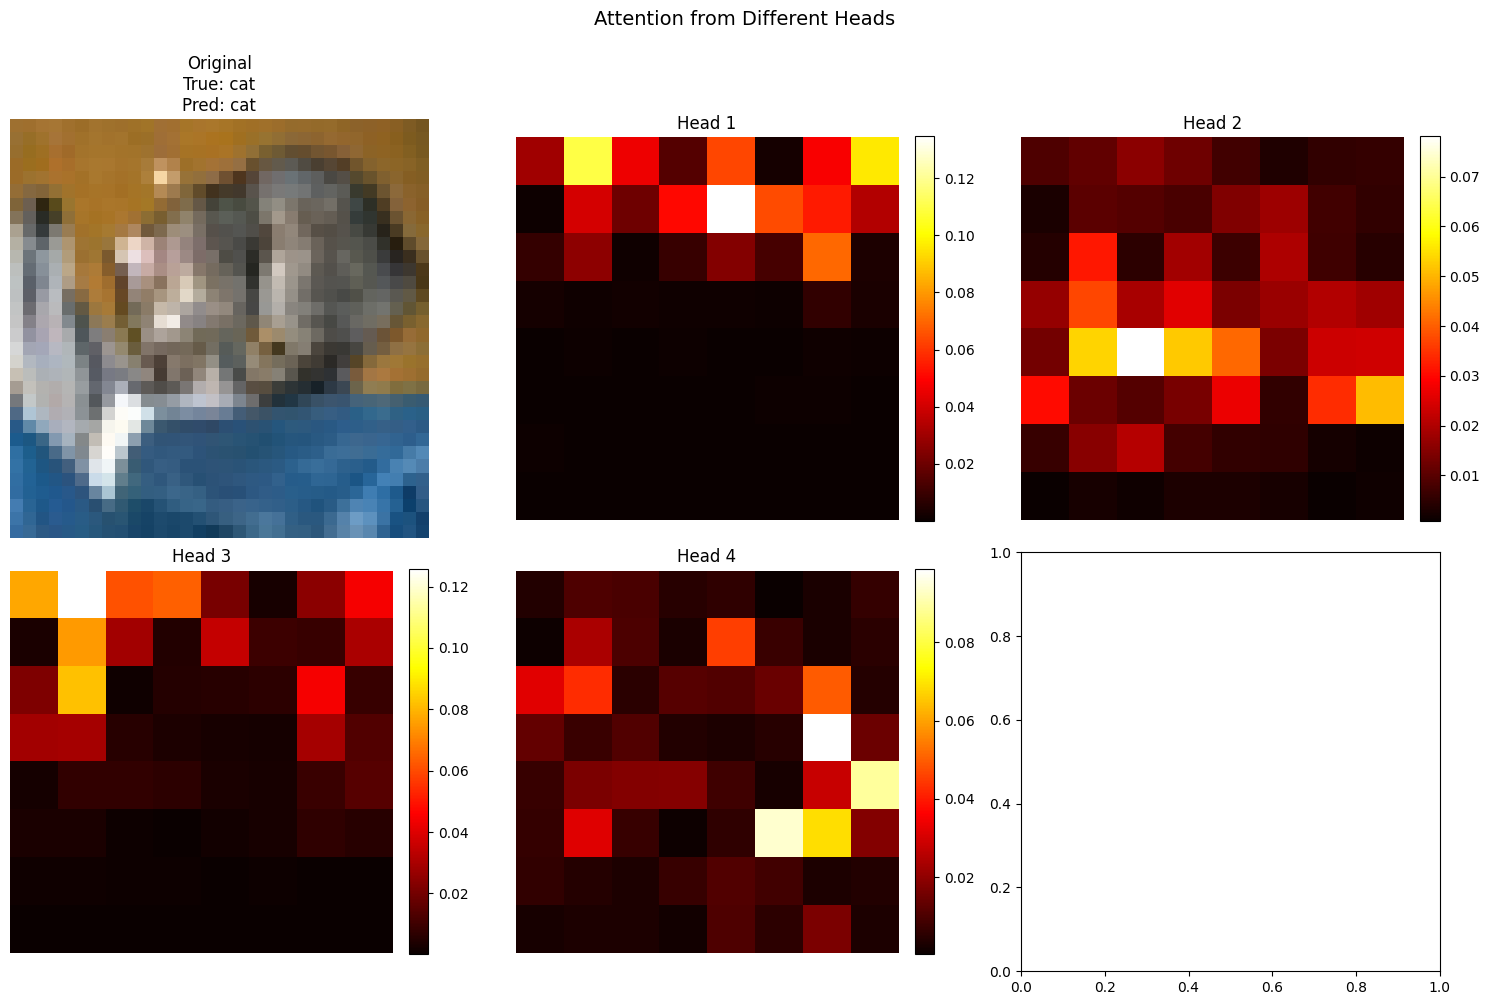


Notice: Different heads learn to attend to different parts!
This is why multi-head attention is powerful.


In [22]:
def visualize_multihead_attention(model, image, label, mean, std):
    """
    Visualize attention from each head separately.
    """
    model.eval()
    
    # Get attention weights
    with torch.no_grad():
        image_batch = image.unsqueeze(0).to(device)
        logits, attention = model(image_batch, return_attention=True)
        
    pred = torch.argmax(logits, dim=1).item()
    
    # Attention from [CLS] token: (num_heads, num_patches)
    cls_attention = attention[0, :, 0, 1:]
    num_heads = cls_attention.shape[0]
    
    # Denormalize image
    from aiml_notebooks import denormalize_image
    image_denorm = denormalize_image(image, mean, std)
    image_np = image_denorm.permute(1, 2, 0).cpu().numpy()
    
    # Visualize each head
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    # Original image
    axes[0].imshow(image_np)
    axes[0].set_title(f'Original\nTrue: {CIFAR10_CLASSES[label]}\nPred: {CIFAR10_CLASSES[pred]}')
    axes[0].axis('off')
    
    # Each attention head
    patch_size = 4
    n_patches_per_side = 32 // patch_size
    
    for head_idx in range(min(num_heads, 5)):
        attention_map = cls_attention[head_idx].reshape(n_patches_per_side, n_patches_per_side)
        attention_map = attention_map.cpu().numpy()
        
        ax = axes[head_idx + 1]
        im = ax.imshow(attention_map, cmap='hot', interpolation='nearest')
        ax.set_title(f'Head {head_idx + 1}')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.suptitle('Attention from Different Heads', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

# Visualize multi-head attention
print("Multi-Head Attention Visualization:\n")
sample_image, sample_label = test_dataset[0]
visualize_multihead_attention(vit, sample_image, sample_label, CIFAR10_MEAN, CIFAR10_STD)

print("\nNotice: Different heads learn to attend to different parts!")
print("This is why multi-head attention is powerful.")

## Part 13: Key Takeaways

### What We Learned

Congratulations! You've built and trained a Vision Transformer from scratch. Let's recap the key insights:

#### 1. Images as Sequences
- Split images into **fixed-size patches** (like words in text)
- Each patch becomes a token in a sequence
- Standard transformer architecture can then be applied

#### 2. Patch Embeddings
- Convolutional projection: efficient patch extraction + embedding
- Class token [CLS]: aggregates information for classification
- Similar to text embeddings, but for image patches

#### 3. Positional Information
- Learnable positional embeddings work well
- Model learns spatial relationships from data
- Alternative: 2D sinusoidal encodings (more explicit)

#### 4. ViT vs CNN Trade-offs

**CNNs**:
- ✅ Strong inductive bias (locality, translation equivariance)
- ✅ Better with small datasets
- ✅ Faster convergence
- ❌ Limited receptive field in early layers
- ❌ Harder to scale

**Vision Transformers**:
- ✅ Global receptive field from layer 1
- ✅ Better scaling with data and compute
- ✅ More flexible (learns spatial structure)
- ✅ Interpretable attention patterns
- ❌ Needs more data to train well
- ❌ Less inductive bias (can be good or bad)

#### 5. Attention Visualization
- We can see what patches the model attends to
- Different heads learn different patterns
- Provides interpretability (unlike CNNs)

### The Big Picture

**Transformers are now competitive across domains**:
- Text: GPT, BERT, T5
- Vision: ViT, Swin Transformer, DeiT
- Multimodal: CLIP, DALL-E, Flamingo
- Video: VideoMAE, TimeSformer
- Audio: Whisper, AudioMAE

The self-attention mechanism is a **universal computation primitive** that works across modalities!

## Part 14: Going Further

### Improvements and Variations

The basic ViT we built can be improved in many ways:

#### 1. Architectural Improvements
- **Hierarchical ViT** (Swin Transformer): Use shifted windows for efficiency
- **Hybrid models**: Combine CNN stem with transformer blocks
- **Distillation**: Train student ViT from teacher CNN (DeiT)

#### 2. Training Improvements
- **Data augmentation**: Strong augmentation (RandAugment, MixUp)
- **Regularization**: Stochastic depth, LayerScale
- **Pre-training**: Self-supervised learning (MAE, DINO)

#### 3. Scaling Up
- Larger models (ViT-Large, ViT-Huge)
- More data (ImageNet-21k, JFT-300M)
- Longer training (300+ epochs)

### Experiments to Try

Deepen your understanding by trying:

1. **Different patch sizes**: Try 8×8 or 2×2
   - How does it affect performance?
   - What about parameter count?

2. **Larger model**: Increase embed_dim to 256
   - Does it improve accuracy?
   - How much slower is training?

3. **Ablation studies**:
   - Remove positional embeddings: Does it still work?
   - Remove class token: Use average pooling instead
   - Single vs multi-head: Compare performance

4. **Attention analysis**:
   - Visualize attention from middle layers
   - Compare attention patterns across classes
   - Study what each head specializes in

### Further Reading

**Papers**:
- Original ViT: "An Image is Worth 16x16 Words" (Dosovitskiy et al., 2020)
- DeiT: "Training data-efficient image transformers" (Touvron et al., 2021)
- Swin Transformer: "Hierarchical Vision Transformer" (Liu et al., 2021)
- MAE: "Masked Autoencoders Are Scalable Vision Learners" (He et al., 2022)

**Resources**:
- Hugging Face Transformers library (timm)
- Official Vision Transformer implementations
- PyTorch Image Models (timm) repository

**Congratulations on mastering Vision Transformers!** 🎉